ПРАКТИКА 11 — ЗАКОН ВЕЛИКИХ ЧИСЕЛ І ЦГТ
Варіант: 4
Місто: Харків
λ = 0.3
Теоретичне E[X] = 3.3333 хв
Теоретичне σ = 3.3333 хв

ЗАВДАННЯ 1. ЗАКОН ВЕЛИКИХ ЧИСЕЛ
n =     5 | середнє = 5.7008 | |x̄ - E[X]| = 2.3675
n =    50 | середнє = 3.8449 | |x̄ - E[X]| = 0.5116
n =   500 | середнє = 3.3448 | |x̄ - E[X]| = 0.0115
n = 20000 | середнє = 3.3158 | |x̄ - E[X]| = 0.0175

Висновок:
Зі збільшенням розміру вибірки вибіркове середнє
загалом наближається до теоретичного E[X].
Це демонструє закон великих чисел.

ЗАВДАННЯ 2. ВИБІРКОВИЙ РОЗПОДІЛ СЕРЕДНЬОГО
Для n=10:
Середнє x̄ = 3.3283
std = 1.0531

Для n=300:
Середнє x̄ = 3.3304
std = 0.1917


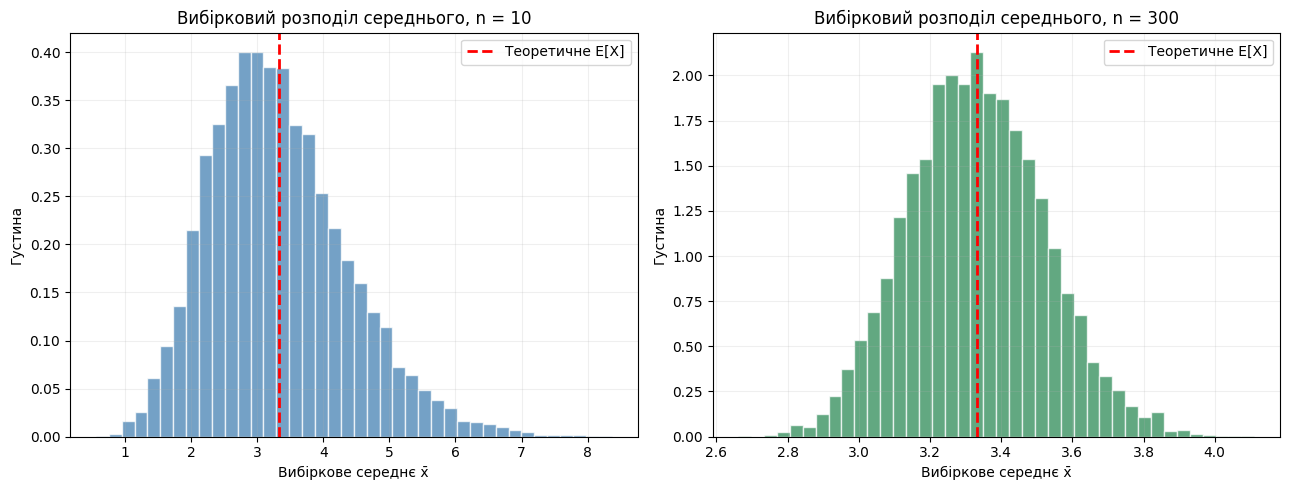


Висновок:
При n=10 розподіл вибіркових середніх ще може бути
помітно скошеним вправо.

При n=300 розподіл стає значно більш симетричним
і наближається до дзвоноподібної нормальної форми.

Це демонструє центральну граничну теорему.

ЗАВДАННЯ 3. СТАНДАРТНА ПОХИБКА
  n  Теоретична SE  Виміряна std
 10       1.054093      1.039509
 30       0.608581      0.610304
100       0.333333      0.332963
300       0.192450      0.192928

Висновок:
Теоретична стандартна похибка та стандартне
відхилення вибіркових середніх, отримане симуляцією,
мають близькі значення.

Невелика різниця пояснюється випадковістю симуляції.
При збільшенні n стандартна похибка зменшується.

ЗАВДАННЯ 4. ЗАКОН УБУВАЮЧОЇ ВІДДАЧІ
SE для n = 25:  0.6667
SE для n = 100: 0.3333

Відношення SE(25) / SE(100) = 2.00

Висновок:
При збільшенні вибірки з 25 до 100 спостережень,
тобто в 4 рази, стандартна похибка зменшується
в 2 рази.

Це пояснюється формулою:
SE = σ / √n

Щоб зменшити стандартну похибку вдвічі,
потрібно збільшити ро

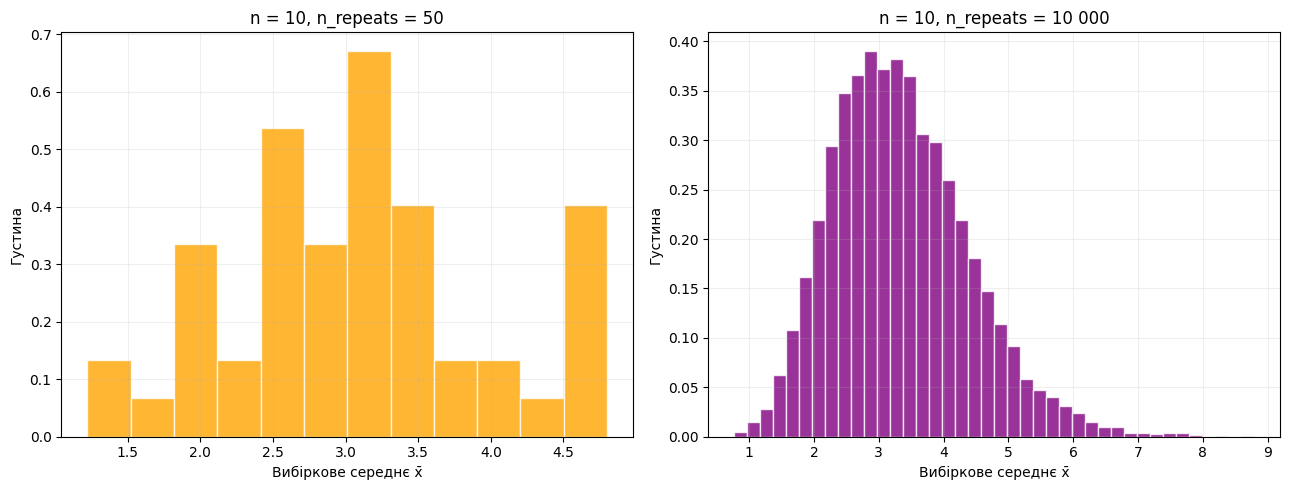


Висновок:
При n_repeats=50 гістограма є менш гладкою та
випадковою, оскільки використано лише 50 значень.

При n_repeats=10 000 гістограма значно гладша
і краще показує справжню форму вибіркового розподілу.

n визначає властивості самого вибіркового середнього,
а n_repeats визначає, наскільки добре ми можемо
побачити його розподіл на гістограмі.

КОНТРОЛЬНІ ПИТАННЯ

1. Закон великих чисел і ЦГТ:

Закон великих чисел відповідає на питання
«куди прямує вибіркове середнє?».
При збільшенні n вибіркове середнє наближається
до теоретичного математичного сподівання E[X].

Центральна гранична теорема відповідає на питання
«якою стає форма та розкид вибіркового середнього?».
При достатньо великому n розподіл вибіркового
середнього наближається до нормального.

------------------------------------------------------------

2. Навіщо використовувати скошений розподіл:

Експоненційний розподіл сильно скошений вправо.
Саме тому він добре демонструє ЦГТ.

Ми бачимо, що навіть із ненормального вихідн

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# ПРАКТИКА 11
# Числові характеристики випадкової величини;
# закон великих чисел і ЦГТ симуляцією
# Варіант 4 — Харків
# ============================================================

# -----------------------------
# Параметри варіанта
# -----------------------------
variant = 4
city = "Харків"
lam = 0.30

# Теоретичні характеристики експоненційного розподілу
true_mean = 1 / lam
true_std = 1 / lam

# Генератор випадкових чисел
rng = np.random.default_rng(variant)

print("=" * 70)
print("ПРАКТИКА 11 — ЗАКОН ВЕЛИКИХ ЧИСЕЛ І ЦГТ")
print("=" * 70)
print(f"Варіант: {variant}")
print(f"Місто: {city}")
print(f"λ = {lam}")
print(f"Теоретичне E[X] = {true_mean:.4f} хв")
print(f"Теоретичне σ = {true_std:.4f} хв")


# ============================================================
# ЗАВДАННЯ 1. Перевірка закону великих чисел
# ============================================================

print("\n" + "=" * 70)
print("ЗАВДАННЯ 1. ЗАКОН ВЕЛИКИХ ЧИСЕЛ")
print("=" * 70)

sample_sizes = [5, 50, 500, 20_000]

zvn_results = []

for n in sample_sizes:
    sample = rng.exponential(
        scale=1 / lam,
        size=n
    )

    sample_mean = sample.mean()
    difference = abs(sample_mean - true_mean)

    zvn_results.append([
        n,
        sample_mean,
        difference
    ])

    print(
        f"n = {n:5d} | "
        f"середнє = {sample_mean:.4f} | "
        f"|x̄ - E[X]| = {difference:.4f}"
    )

print("""
Висновок:
Зі збільшенням розміру вибірки вибіркове середнє
загалом наближається до теоретичного E[X].
Це демонструє закон великих чисел.
""")


# ============================================================
# ЗАВДАННЯ 2. Вибірковий розподіл середнього
# ============================================================

print("=" * 70)
print("ЗАВДАННЯ 2. ВИБІРКОВИЙ РОЗПОДІЛ СЕРЕДНЬОГО")
print("=" * 70)

n_repeats = 10_000

# 10 000 вибірок по 10 спостережень
samples_n10 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 10)
)

sample_means_10 = samples_n10.mean(axis=1)

# 10 000 вибірок по 300 спостережень
samples_n300 = rng.exponential(
    scale=1 / lam,
    size=(n_repeats, 300)
)

sample_means_300 = samples_n300.mean(axis=1)

print(f"Для n=10:")
print(f"Середнє x̄ = {sample_means_10.mean():.4f}")
print(f"std = {sample_means_10.std():.4f}")

print(f"\nДля n=300:")
print(f"Середнє x̄ = {sample_means_300.mean():.4f}")
print(f"std = {sample_means_300.std():.4f}")


# Гістограми
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    sample_means_10,
    bins=40,
    density=True,
    edgecolor="white",
    alpha=0.75,
    color="steelblue"
)

axes[0].axvline(
    true_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Теоретичне E[X]"
)

axes[0].set_title("Вибірковий розподіл середнього, n = 10")
axes[0].set_xlabel("Вибіркове середнє x̄")
axes[0].set_ylabel("Густина")
axes[0].legend()
axes[0].grid(alpha=0.2)


axes[1].hist(
    sample_means_300,
    bins=40,
    density=True,
    edgecolor="white",
    alpha=0.75,
    color="seagreen"
)

axes[1].axvline(
    true_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Теоретичне E[X]"
)

axes[1].set_title("Вибірковий розподіл середнього, n = 300")
axes[1].set_xlabel("Вибіркове середнє x̄")
axes[1].set_ylabel("Густина")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("""
Висновок:
При n=10 розподіл вибіркових середніх ще може бути
помітно скошеним вправо.

При n=300 розподіл стає значно більш симетричним
і наближається до дзвоноподібної нормальної форми.

Це демонструє центральну граничну теорему.
""")


# ============================================================
# ЗАВДАННЯ 3. Стандартна похибка:
# теорія проти симуляції
# ============================================================

print("=" * 70)
print("ЗАВДАННЯ 3. СТАНДАРТНА ПОХИБКА")
print("=" * 70)

n_values = [10, 30, 100, 300]

results = []

for n in n_values:

    # Повторні вибірки
    samples = rng.exponential(
        scale=1 / lam,
        size=(n_repeats, n)
    )

    # Середнє кожної вибірки
    sample_means = samples.mean(axis=1)

    # Теоретична SE
    se_theoretical = true_std / np.sqrt(n)

    # Виміряна SE через std вибіркових середніх
    se_simulated = sample_means.std()

    results.append([
        n,
        se_theoretical,
        se_simulated
    ])

# Таблиця
df = pd.DataFrame(
    results,
    columns=[
        "n",
        "Теоретична SE",
        "Виміряна std"
    ]
)

print(df.to_string(index=False))

print("""
Висновок:
Теоретична стандартна похибка та стандартне
відхилення вибіркових середніх, отримане симуляцією,
мають близькі значення.

Невелика різниця пояснюється випадковістю симуляції.
При збільшенні n стандартна похибка зменшується.
""")


# ============================================================
# ЗАВДАННЯ 4. Закон убуваючої віддачі
# ============================================================

print("=" * 70)
print("ЗАВДАННЯ 4. ЗАКОН УБУВАЮЧОЇ ВІДДАЧІ")
print("=" * 70)

n1 = 25
n2 = 100

se_25 = true_std / np.sqrt(n1)
se_100 = true_std / np.sqrt(n2)

print(f"SE для n = 25:  {se_25:.4f}")
print(f"SE для n = 100: {se_100:.4f}")

print(f"\nВідношення SE(25) / SE(100) = {se_25 / se_100:.2f}")

print("""
Висновок:
При збільшенні вибірки з 25 до 100 спостережень,
тобто в 4 рази, стандартна похибка зменшується
в 2 рази.

Це пояснюється формулою:
SE = σ / √n

Щоб зменшити стандартну похибку вдвічі,
потрібно збільшити розмір вибірки в 4 рази.
""")


# ============================================================
# ЗАВДАННЯ 5. ДОДАТКОВЕ
# Вплив n_repeats на якість симуляції
# ============================================================

print("=" * 70)
print("ЗАВДАННЯ 5. ВПЛИВ n_repeats")
print("=" * 70)

# 50 повторних вибірок по 10 значень
sample_means_50 = rng.exponential(
    scale=1 / lam,
    size=(50, 10)
).mean(axis=1)

# 10 000 повторних вибірок по 10 значень
sample_means_10000 = rng.exponential(
    scale=1 / lam,
    size=(10_000, 10)
).mean(axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(
    sample_means_50,
    bins=12,
    density=True,
    edgecolor="white",
    alpha=0.8,
    color="orange"
)

axes[0].set_title(
    "n = 10, n_repeats = 50"
)
axes[0].set_xlabel("Вибіркове середнє x̄")
axes[0].set_ylabel("Густина")
axes[0].grid(alpha=0.2)


axes[1].hist(
    sample_means_10000,
    bins=40,
    density=True,
    edgecolor="white",
    alpha=0.8,
    color="purple"
)

axes[1].set_title(
    "n = 10, n_repeats = 10 000"
)
axes[1].set_xlabel("Вибіркове середнє x̄")
axes[1].set_ylabel("Густина")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("""
Висновок:
При n_repeats=50 гістограма є менш гладкою та
випадковою, оскільки використано лише 50 значень.

При n_repeats=10 000 гістограма значно гладша
і краще показує справжню форму вибіркового розподілу.

n визначає властивості самого вибіркового середнього,
а n_repeats визначає, наскільки добре ми можемо
побачити його розподіл на гістограмі.
""")


# ============================================================
# ПІДСУМКОВІ КОНТРОЛЬНІ ПИТАННЯ
# ============================================================

print("=" * 70)
print("КОНТРОЛЬНІ ПИТАННЯ")
print("=" * 70)

print("""
1. Закон великих чисел і ЦГТ:

Закон великих чисел відповідає на питання
«куди прямує вибіркове середнє?».
При збільшенні n вибіркове середнє наближається
до теоретичного математичного сподівання E[X].

Центральна гранична теорема відповідає на питання
«якою стає форма та розкид вибіркового середнього?».
При достатньо великому n розподіл вибіркового
середнього наближається до нормального.

------------------------------------------------------------

2. Навіщо використовувати скошений розподіл:

Експоненційний розподіл сильно скошений вправо.
Саме тому він добре демонструє ЦГТ.

Ми бачимо, що навіть із ненормального вихідного
розподілу розподіл вибіркового середнього при
збільшенні n стає приблизно нормальним.

Якби вихідні дані одразу були нормальними,
такого переходу було б складніше продемонструвати.

------------------------------------------------------------

3. Чому SE зменшується як √n:

Стандартна похибка визначається формулою:

SE = σ / √n

Тому збільшення n у 4 рази збільшує √n лише
у 2 рази, а стандартна похибка зменшується
у 2 рази.

Отже, щоб зменшити похибку вдвічі, потрібно
приблизно вчетверо збільшити кількість спостережень.
""")

print("=" * 70)
print("ПРАКТИКУ 11 ЗАВЕРШЕНО")
print("=" * 70)

